# 11: Interventions and Counterfactuals with GCM

The previous lesson introduced graphical causal models as causal graphs plus fitted node-level mechanisms. We use those fitted mechanisms for the two questions people usually want from a structural causal model:

- **Intervention question:** What would the distribution of an outcome look like if we changed a system lever for everyone?
- **Counterfactual question:** For this specific observed unit, what would have happened if one part of its causal history had been different?

Those sound similar, but they are not the same object. An intervention creates a new data-generating world. A counterfactual keeps the same unit-level background factors, infers the unit's structural noise, changes one part of the world, and then propagates the consequences through the graph.

The lesson uses a small recommendation-style system because the variables are intuitive, but the workflow is general: specify a graph, fit an invertible GCM, simulate interventions, compute average causal effects, and then answer row-level what-if questions.


## Learning Goals

By the end, you should be able to:

- Explain the difference between observational samples, interventional samples, and counterfactual samples.
- Fit an `InvertibleStructuralCausalModel` that can answer individual counterfactual questions.
- Use `gcm.interventional_samples` to simulate a policy-like change.
- Use `gcm.average_causal_effect` to compare two intervention worlds.
- Use `gcm.counterfactual_samples` to ask what would have happened to specific observed rows.
- Check whether the fitted GCM gives reasonable answers by comparing with the known simulator used for this example data.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Interventions And Counterfactuals With GCM**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment uses a structural causal model, so the important object is the collection of mechanisms, more than a single treatment coefficient. The experiment asks what would change under an intervention on a variable or mechanism. That makes the data-generating story especially important.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

A graphical causal model writes each variable as a structural assignment,

$$
X_j := f_j(X_{\operatorname{pa}(j)},N_j), \qquad N_j \perp\!\!\!\perp N_k \text{ for } j\neq k.
$$

An intervention replaces one assignment,

$$
X_t := x.
$$

Interventional and counterfactual queries modify the data-generating process and then trace how the changed mechanism propagates.


## Why This Lesson Matters

Classic treatment-effect lessons usually focus on one number: the average effect of treatment on an outcome. That is useful, but many real product, policy, and operations questions are richer:

- What if we raise the quality of recommendations for everyone by a small amount?
- What if we apply a prompt only when it is likely to help downstream behavior?
- Which users would have had meaningfully different outcomes under a better upstream experience?
- How do we separate a population-level intervention effect from a row-level counterfactual explanation?

A fitted GCM gives a practical way to explore these questions, as long as we remember the main caveat: the answers are only as credible as the graph assumptions, observed variables, and fitted mechanisms.





## Tutorial Workflow

#### Setup

The code below imports the libraries, configures plotting, creates output folders, and suppresses warnings that are known to be non-actionable for this tutorial environment. We also turn off DoWhy GCM progress bars so the executed lesson stays readable.


In [ ]:
from pathlib import Path
import os
import warnings
# Keep Matplotlib from trying to write cache files under a non-writable home config path.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")
# Keep warnings visible by default, then silence noisy library warnings that do not affect this lesson.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
from IPython.display import display
from dowhy import gcm
import dowhy
# Reproducibility matters because GCM simulation draws new samples.
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
# Shared tutorial output folders.
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
# DoWhy GCM progress bars are useful interactively, but noisy in a saved teaching notebook.
gcm.config.show_progress_bars = False
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")


The environment is ready once the DoWhy version and output folders print. Every saved output in this lesson uses an `11_` prefix so it is easy to distinguish from the earlier tutorial outputs.


### Concept Map

Before writing code, it helps to separate the three sampling modes used in this lesson. They all use the same graph vocabulary, but they answer different questions.


| object | notation | question answered | what changes |
| --- | --- | --- | --- |
| observational sample | P(Y, X) | What patterns appear in the data-generating process we observed? | Nothing; we sample from the fitted natural system. |
| interventional sample | P(Y \| do(A = a)) | What would the population look like under a changed system rule? | The mechanism for an intervened node is replaced by the intervention rule. |
| average causal effect | E[Y \| do(A = a)] - E[Y \| do(A = a') ] | How different are two intervention worlds on average? | Two intervention worlds are compared for the same target node. |
| counterfactual sample | Y_{A=a}(u) | For this observed row, what would have happened under a different causal history? | The row's inferred background noise is preserved, then the intervention is propagated. |


The important practical difference is the unit of analysis. Interventions are population simulations. Counterfactuals are row-level what-if reconstructions. A fitted GCM can support both, but we should not blur them together.


### Teaching Scenario

We will simulate a compact system with six observed variables:

- `user_intent`: baseline demand or motivation before the recommendation experience.
- `catalog_match`: how well the available catalog matches the user's interests.
- `tutorial_prompt`: intensity of an onboarding or help prompt.
- `recommendation_quality`: quality of the ranked items shown to the user.
- `watch_time`: short-term engagement after the experience.
- `next_week_value`: later value, satisfaction, or retention-like outcome.

The upstream nodes are not treatments in the classic binary sense. They are continuous system levers or context variables. GCM interventions are well suited for this kind of continuous what-if analysis.


| column | role in graph | plain meaning | why it matters |
| --- | --- | --- | --- |
| user_intent | root context variable | A pre-experience measure of how motivated the user is. | It affects recommendation quality, watch time, and later value. |
| catalog_match | root context variable | How well available content matches the user's interests. | It affects the achievable quality of recommendations. |
| tutorial_prompt | root system variable | Intensity of guidance, education, or onboarding prompt. | It can raise short-term engagement but may also have a direct friction cost. |
| recommendation_quality | intervention candidate | Quality of ranked content shown to the user. | It directly affects later value and indirectly affects it through watch time. |
| watch_time | mediating outcome | Short-term engagement after exposure. | It transmits part of the effect of recommendation quality to later value. |
| next_week_value | target outcome | A later value metric measured after the experience. | This is the target we want to improve or explain. |


This table is the lesson's data dictionary. The causal roles are explicit because interventions and counterfactuals only make sense after we state what each variable means and when it occurs.


#### Simulate a Known Structural System

The next step creates the example dataset. We keep the structural noise terms outside the modeling dataframe so the fitted GCM only sees realistic observed columns. The hidden noise terms are retained separately for one later sanity check against the known simulator.


In [2]:
N = 4_000
# Root variables: these are sampled before the downstream experience occurs.
user_intent = rng.normal(0, 1, size=N)
catalog_match = rng.normal(0, 1, size=N)
tutorial_prompt = rng.normal(0, 1, size=N)
# Structural noise terms. These are not included as observed model features.
eps_quality = rng.normal(0, 0.35, size=N)
eps_watch = rng.normal(0, 0.45, size=N)
eps_value = rng.normal(0, 0.50, size=N)
# Nonlinear but still readable structural equations.
recommendation_quality = (
    0.55 * user_intent
    + 0.35 * catalog_match
    + 0.18 * user_intent * catalog_match
    + eps_quality
)
watch_time = (
    1.10
    + 0.75 * recommendation_quality
    + 0.25 * tutorial_prompt
    + 0.35 * user_intent
    + 0.18 * recommendation_quality * user_intent
    + eps_watch
)
next_week_value = (
    0.35 * recommendation_quality
    + 0.60 * watch_time
    + 0.20 * user_intent
    - 0.10 * tutorial_prompt
    + 0.08 * watch_time * user_intent
    + eps_value
)
gcm_df = pd.DataFrame(
    {
        "user_intent": user_intent,
        "catalog_match": catalog_match,
        "tutorial_prompt": tutorial_prompt,
        "recommendation_quality": recommendation_quality,
        "watch_time": watch_time,
        "next_week_value": next_week_value,
    }
)
# Store the unobserved structural noise separately for a later oracle comparison.
structural_noise = pd.DataFrame(
    {
        "eps_quality": eps_quality,
        "eps_watch": eps_watch,
        "eps_value": eps_value,
    }
)
gcm_df.to_csv(TABLE_DIR / "11_teaching_dataset.csv", index=False)
display(gcm_df.head())


,user_intent,catalog_match,tutorial_prompt,recommendation_quality,watch_time,next_week_value
0,-0.7931,1.4960,-0.1195,0.3934,0.4390,0.6109
1,0.2406,-0.9171,0.4444,-0.8363,1.2277,-0.0032
2,-1.8963,0.0238,0.1472,-0.7157,-0.0269,-0.7831
3,1.3958,-0.9931,-1.4642,0.2457,0.7810,1.7102
4,0.6383,0.4032,-0.3150,0.4026,2.1148,2.0118


The preview shows only observed variables. The true noise terms are available to us as analysts, but the fitted GCM will have to infer residual variation from the observed data and graph.


### Basic Data Checks

Before fitting a structural model, we check scale, missingness, and rough distributions. This is a modeling hygiene step, not a causal claim. It tells us whether the generated data look reasonable enough for the rest of the tutorial.


In [3]:
summary = (
    gcm_df.describe()
    .T
    .assign(missing_rate=gcm_df.isna().mean())
    .reset_index(names="column")
)
summary.to_csv(TABLE_DIR / "11_numeric_summary.csv", index=False)
display(summary)


,column,count,mean,std,min,25%,50%,75%,max,missing_rate
0,user_intent,"4,000.0000",-0.0161,1.0086,-3.7474,-0.7112,0.0066,0.6774,3.6210,0.0000
1,catalog_match,"4,000.0000",0.0131,1.0093,-3.9877,-0.6805,0.0306,0.7038,3.4176,0.0000
2,tutorial_prompt,"4,000.0000",-0.0064,0.9948,-3.5867,-0.6929,-0.0014,0.6691,3.6675,0.0000
3,recommendation_quality,"4,000.0000",-0.0063,0.7776,-2.6874,-0.5476,-0.0727,0.4947,3.8119,0.0000
4,watch_time,"4,000.0000",1.2006,1.0413,-1.7743,0.4635,1.0802,1.8435,7.9239,0.0000
5,next_week_value,"4,000.0000",0.7805,1.2441,-2.4844,-0.0882,0.6512,1.5406,8.2980,0.0000


There are no missing values, and the scales are deliberately modest. Keeping the variables on comparable scales makes the intervention sizes easier to reason about later.





## Diagnostics and Interpretation

### Observed Correlations

Correlations are limited as causal effects. They are still a useful first look. If the graph says one variable affects another, we expect compatible marginal patterns unless the effect is masked by competing pathways.


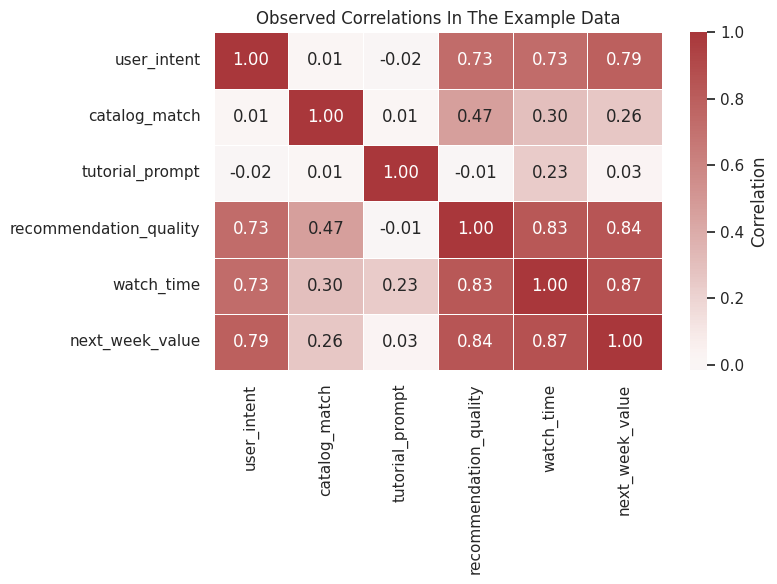

In [4]:
corr = gcm_df.corr(numeric_only=True)
corr.to_csv(TABLE_DIR / "11_observed_correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Observed Correlations In The Example Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_observed_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap shows the expected positive association between recommendation quality, watch time, and next-week value. The tutorial prompt has a more subtle pattern because it helps watch time but has a small direct friction cost in the outcome equation.




### Specify the Causal Graph

The graph encodes the causal order we want the GCM to respect. Root variables come first. Recommendation quality then affects watch time and next-week value. Watch time also affects next-week value, so it acts as a mediator for part of the recommendation-quality effect.


In [5]:
causal_edges = [
    ("user_intent", "recommendation_quality"),
    ("catalog_match", "recommendation_quality"),
    ("user_intent", "watch_time"),
    ("recommendation_quality", "watch_time"),
    ("tutorial_prompt", "watch_time"),
    ("user_intent", "next_week_value"),
    ("recommendation_quality", "next_week_value"),
    ("watch_time", "next_week_value"),
    ("tutorial_prompt", "next_week_value"),
]
causal_graph = nx.DiGraph(causal_edges)
edge_table = pd.DataFrame(causal_edges, columns=["cause", "effect"])
edge_table.to_csv(TABLE_DIR / "11_causal_graph_edges.csv", index=False)
display(edge_table)


,cause,effect
0,user_intent,recommendation_quality
1,catalog_match,recommendation_quality
2,user_intent,watch_time
3,recommendation_quality,watch_time
4,tutorial_prompt,watch_time
5,user_intent,next_week_value
6,recommendation_quality,next_week_value
7,watch_time,next_week_value
8,tutorial_prompt,next_week_value


The edge list is the formal causal design for this lesson. When we later intervene on `recommendation_quality`, the effect can flow directly into `next_week_value` and indirectly through `watch_time`.


#### Visualize the Graph

A clear graph is especially useful for counterfactual work because it shows which downstream nodes are recomputed after an intervention and which upstream variables stay fixed.


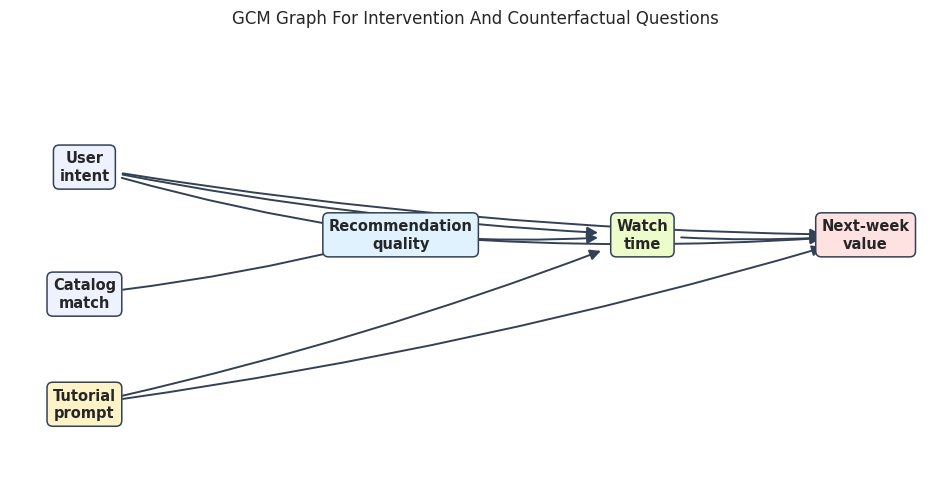

In [6]:
positions = {
    "user_intent": (0.08, 0.72),
    "catalog_match": (0.08, 0.42),
    "tutorial_prompt": (0.08, 0.16),
    "recommendation_quality": (0.42, 0.56),
    "watch_time": (0.68, 0.56),
    "next_week_value": (0.92, 0.56),
}
node_colors = {
    "user_intent": "#eef2ff",
    "catalog_match": "#eef2ff",
    "tutorial_prompt": "#fef3c7",
    "recommendation_quality": "#e0f2fe",
    "watch_time": "#ecfccb",
    "next_week_value": "#fee2e2",
}
node_labels = {
    "user_intent": "User\nintent",
    "catalog_match": "Catalog\nmatch",
    "tutorial_prompt": "Tutorial\nprompt",
    "recommendation_quality": "Recommendation\nquality",
    "watch_time": "Watch\ntime",
    "next_week_value": "Next-week\nvalue",
}
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_axis_off()
# Draw arrows first, using shrink values so arrowheads stop at the edge of the text boxes.
for source, target in causal_edges:
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.4,
            shrinkA=28,
            shrinkB=32,
            mutation_scale=16,
            connectionstyle="arc3,rad=0.04",
        ),
    )
# Draw labeled boxes after arrows so node labels stay readable.
for node, (x, y) in positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.40",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.1,
        ),
    )
ax.set_title("GCM Graph For Intervention And Counterfactual Questions", pad=18)
fig.savefig(FIGURE_DIR / "11_gcm_intervention_graph.png", dpi=160, bbox_inches="tight")
plt.show()


The graph highlights the two main levers used later: `recommendation_quality` and `tutorial_prompt`. It also shows why changing recommendation quality can move the outcome through more than one path.


#### Build an Invertible Structural Causal Model

For ordinary interventional sampling, a `StructuralCausalModel` is enough. For row-level counterfactuals, DoWhy needs enough structure to infer the unit-specific noise values. We therefore use `InvertibleStructuralCausalModel` and assign additive-noise mechanisms to non-root nodes.


In [7]:
causal_model = gcm.InvertibleStructuralCausalModel(causal_graph)
root_nodes = ["user_intent", "catalog_match", "tutorial_prompt"]
child_nodes = ["recommendation_quality", "watch_time", "next_week_value"]
# Root nodes are modeled with their empirical marginal distributions.
for node in root_nodes:
    causal_model.set_causal_mechanism(node, gcm.EmpiricalDistribution())
# Child nodes use flexible nonlinear regressors inside additive-noise mechanisms.
for node in child_nodes:
    causal_model.set_causal_mechanism(
        node,
        gcm.AdditiveNoiseModel(
            gcm.ml.create_hist_gradient_boost_regressor(
                max_iter=80,
                max_leaf_nodes=16,
                learning_rate=0.06,
                random_state=RANDOM_SEED,
            )
        ),
    )
mechanism_table = pd.DataFrame(
    [
        {
            "node": node,
            "parents": ", ".join(causal_graph.predecessors(node)) or "none",
            "mechanism": type(causal_model.causal_mechanism(node)).__name__,
        }
        for node in causal_graph.nodes
    ]
)
mechanism_table.to_csv(TABLE_DIR / "11_assigned_mechanisms.csv", index=False)
display(mechanism_table)


,node,parents,mechanism
0,user_intent,none,EmpiricalDistribution
1,recommendation_quality,"user_intent, catalog_match",AdditiveNoiseModel
2,catalog_match,none,EmpiricalDistribution
3,watch_time,"user_intent, recommendation_quality, tutorial_prompt",AdditiveNoiseModel
4,tutorial_prompt,none,EmpiricalDistribution
5,next_week_value,"user_intent, recommendation_quality, watch_time, tutorial_prompt",AdditiveNoiseModel


The table shows the model structure DoWhy will fit. Root variables get empirical distributions, while downstream variables get learned structural equations plus residual noise.


#### Fit the GCM

Fitting estimates each node-level mechanism from the observed dataset. For a child node, this means learning how the node depends on its parents and how much residual variation remains after that relationship is modeled.


In [8]:
# Fit every mechanism in topological order according to the graph.
gcm.fit(causal_model, gcm_df)
fit_status = pd.DataFrame(
    [
        {
            "node": node,
            "fitted_mechanism": type(causal_model.causal_mechanism(node)).__name__,
            "has_parents": causal_graph.in_degree(node) > 0,
        }
        for node in causal_graph.nodes
    ]
)
fit_status.to_csv(TABLE_DIR / "11_fitted_mechanisms.csv", index=False)
display(fit_status)


,node,fitted_mechanism,has_parents
0,user_intent,EmpiricalDistribution,False
1,recommendation_quality,AdditiveNoiseModel,True
2,catalog_match,EmpiricalDistribution,False
3,watch_time,AdditiveNoiseModel,True
4,tutorial_prompt,EmpiricalDistribution,False
5,next_week_value,AdditiveNoiseModel,True


The model is now fitted and can generate observational, interventional, and counterfactual samples. The next few sections use the same fitted object in different modes.


#### Draw Observational Samples from the Fitted Model

Before asking what-if questions, we check whether the fitted GCM can reproduce the natural distribution of the observed system. This serves a different role than a proof of causal validity. It is a basic sanity check for the fitted mechanisms.


In [9]:
model_samples = gcm.draw_samples(causal_model, num_samples=4_000)
observed_vs_model_summary = pd.concat(
    [
        gcm_df.agg(["mean", "std", "min", "max"]).T.assign(source="observed"),
        model_samples.agg(["mean", "std", "min", "max"]).T.assign(source="gcm_generated"),
    ]
    ).reset_index(names="column")
observed_vs_model_summary.to_csv(TABLE_DIR / "11_observed_vs_model_summary.csv", index=False)
display(observed_vs_model_summary.head(12))


,column,mean,std,min,max,source
0,user_intent,-0.0161,1.0086,-3.7474,3.6210,observed
1,catalog_match,0.0131,1.0093,-3.9877,3.4176,observed
2,tutorial_prompt,-0.0064,0.9948,-3.5867,3.6675,observed
3,recommendation_quality,-0.0063,0.7776,-2.6874,3.8119,observed
4,watch_time,1.2006,1.0413,-1.7743,7.9239,observed
5,next_week_value,0.7805,1.2441,-2.4844,8.2980,observed
6,user_intent,-0.0088,1.0133,-3.5616,3.3335,gcm_generated
7,catalog_match,0.0121,1.0108,-3.2723,3.4176,gcm_generated
8,tutorial_prompt,0.0074,1.0082,-3.5867,3.6003,gcm_generated
9,recommendation_quality,-0.0118,0.7625,-2.3494,2.9530,gcm_generated


The generated sample roughly matches the observed means and spreads. That gives us enough confidence to use the model for learning interventions, while still remembering that distributional fit is only one diagnostic.




### Compare Observed and Generated Distributions

A visual check catches mismatches that a summary table can hide. Here we compare the observed and generated distributions for the main downstream variables.


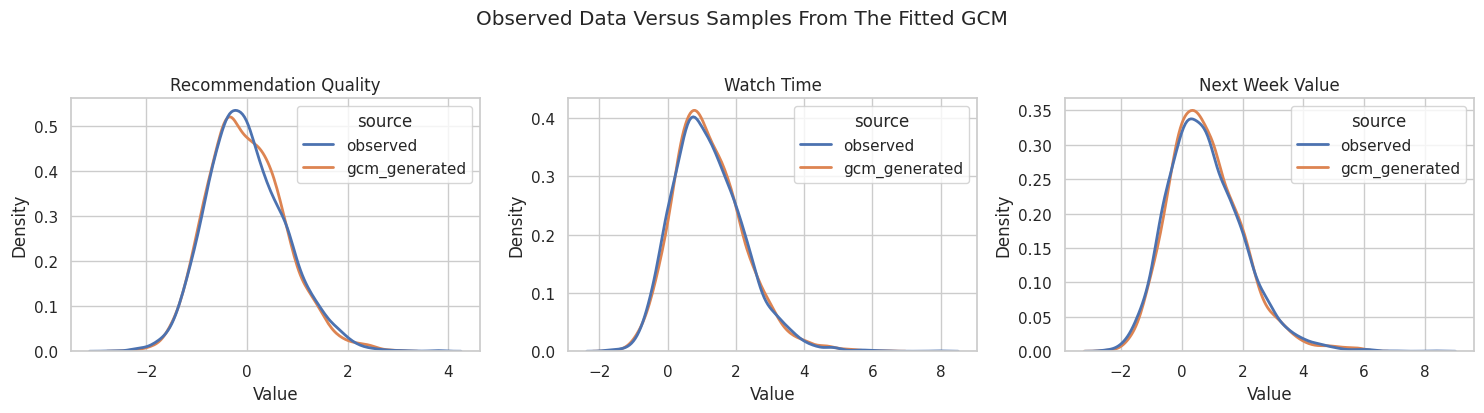

In [10]:
# Build and label the diagnostic visualization for the Compare Observed And Generated Distributions section.
plot_df = pd.concat(
    [
        gcm_df[["recommendation_quality", "watch_time", "next_week_value"]].assign(source="observed"),
        model_samples[["recommendation_quality", "watch_time", "next_week_value"]].assign(source="gcm_generated"),
    ],
    ignore_index=True,
)
long_plot_df = plot_df.melt(id_vars="source", var_name="variable", value_name="value")
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, variable in zip(axes, ["recommendation_quality", "watch_time", "next_week_value"]):
    sns.kdeplot(
        data=long_plot_df[long_plot_df["variable"] == variable],
        x="value",
        hue="source",
        common_norm=False,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(variable.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
fig.suptitle("Observed Data Versus Samples From The Fitted GCM", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_observed_vs_gcm_generated_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The fitted model captures the broad shape of the downstream distributions. That is the minimum standard we want before using the GCM as a simulation engine for policy-like changes.




#### Define Intervention Helper Functions

DoWhy GCM interventions are passed as functions. The function receives the naturally generated values for a node and returns the intervened values. This makes it easy to write both hard interventions such as setting a value to a constant and soft interventions such as shifting a value upward.


In [11]:
# Define reusable helpers for the Define Intervention Helper Functions section.
def identity_intervention(values):
    """
    Leave a generated node unchanged; useful as a reference intervention.
    
    Parameters
    ----------
    values : array-like
        Numeric values transformed, standardized, summarized, or plotted by the helper.
    
    Returns
    -------
    array-like
        Input values returned unchanged for a no-op intervention.
    """
    return values
def shift_by(amount):
    """
    Create a soft intervention that shifts a node by a fixed amount.
    
    Parameters
    ----------
    amount : object
        Intervention value used to set the target variable in the GCM example.
    
    Returns
    -------
    callable
        Intervention function that adds the requested shift amount to incoming values.
    """
    return lambda values: values + amount
def set_to(value):
    """
    Create a hard intervention that replaces a node with a constant.
    
    Parameters
    ----------
    value : object
        Input value normalized or converted by the helper.
    
    Returns
    -------
    callable
        Intervention function that replaces a variable with the requested fixed value.
    """
    return lambda values: np.full_like(values, fill_value=value, dtype=float)
intervention_examples = pd.DataFrame(
    [
        {
            "intervention function": "identity_intervention",
            "example": "A -> A",
            "meaning": "Reference world with no change to the generated node.",
        },
        {
            "intervention function": "shift_by(0.5)",
            "example": "A -> A + 0.5",
            "meaning": "Soft policy improvement that preserves relative differences.",
        },
        {
            "intervention function": "set_to(1.0)",
            "example": "A -> 1.0",
            "meaning": "Hard intervention that forces the same value for everyone.",
        },
    ]
)
intervention_examples.to_csv(TABLE_DIR / "11_intervention_function_examples.csv", index=False)
display(intervention_examples)


,intervention function,example,meaning
0,identity_intervention,A -> A,Reference world with no change to the generated node.
1,shift_by(0.5),A -> A + 0.5,Soft policy improvement that preserves relative differences.
2,set_to(1.0),A -> 1.0,Hard intervention that forces the same value for everyone.


The tutorial will mostly use soft shifts because they are easier to interpret for continuous quality metrics. A hard intervention is still useful when the question is about setting a system variable to a fixed target.


#### Simulate a Soft Recommendation-Quality Intervention

Now we ask a population-level question: what would the system look like if recommendation quality were improved by `0.5` units for everyone? This is a soft intervention because each sampled unit keeps its natural relative position, then receives the same upward shift.


In [12]:
quality_shift_intervention = {"recommendation_quality": shift_by(0.5)}
quality_shift_samples = gcm.interventional_samples(
    causal_model,
    interventions=quality_shift_intervention,
    num_samples_to_draw=4_000,
)
quality_shift_summary = pd.DataFrame(
    {
        "observed_mean": gcm_df[["recommendation_quality", "watch_time", "next_week_value"]].mean(),
        "intervention_mean": quality_shift_samples[["recommendation_quality", "watch_time", "next_week_value"]].mean(),
    }
).assign(mean_difference=lambda frame: frame["intervention_mean"] - frame["observed_mean"])
quality_shift_summary = quality_shift_summary.reset_index(names="variable")
quality_shift_summary.to_csv(TABLE_DIR / "11_quality_shift_intervention_summary.csv", index=False)
display(quality_shift_summary)


,variable,observed_mean,intervention_mean,mean_difference
0,recommendation_quality,-0.0063,0.4841,0.4904
1,watch_time,1.2006,1.5981,0.3974
2,next_week_value,0.7805,1.2267,0.4462


The intervention directly raises recommendation quality and also raises downstream watch time and next-week value. Those downstream changes occur because the GCM propagates the intervention through the graph.




#### Visualize the Intervention Distribution Shift

A mean comparison is compact, but a distribution plot shows whether the whole population shifts or whether only the tails move.


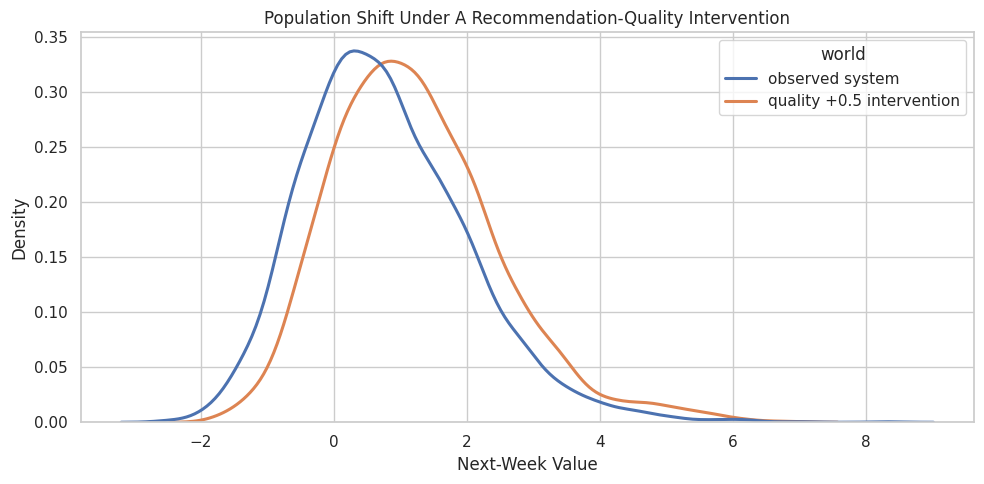

In [13]:
intervention_plot_df = pd.concat(
    [
        gcm_df[["next_week_value"]].assign(world="observed system"),
        quality_shift_samples[["next_week_value"]].assign(world="quality +0.5 intervention"),
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=intervention_plot_df,
    x="next_week_value",
    hue="world",
    common_norm=False,
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Population Shift Under A Recommendation-Quality Intervention")
ax.set_xlabel("Next-Week Value")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_quality_shift_next_week_value_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The intervention shifts the next-week value distribution to the right. This is a population-level picture: it does not say what would have happened to any specific observed row.




### Estimate Average Causal Effects with GCM

`gcm.average_causal_effect` compares two intervention worlds. Here the alternative world shifts recommendation quality upward by `0.5`, while the reference world leaves recommendation quality unchanged.


In [14]:
# Use a fixed observed base sample so different effect estimates are comparable.
ace_base = gcm_df.sample(2_500, random_state=RANDOM_SEED).reset_index(drop=True)
quality_ace = gcm.average_causal_effect(
    causal_model,
    target_node="next_week_value",
    interventions_alternative={"recommendation_quality": shift_by(0.5)},
    interventions_reference={"recommendation_quality": identity_intervention},
    observed_data=ace_base,
)
watch_ace = gcm.average_causal_effect(
    causal_model,
    target_node="next_week_value",
    interventions_alternative={"watch_time": shift_by(0.5)},
    interventions_reference={"watch_time": identity_intervention},
    observed_data=ace_base,
)
prompt_ace = gcm.average_causal_effect(
    causal_model,
    target_node="next_week_value",
    interventions_alternative={"tutorial_prompt": shift_by(0.5)},
    interventions_reference={"tutorial_prompt": identity_intervention},
    observed_data=ace_base,
)
ace_table = pd.DataFrame(
    [
        {
            "intervened_node": "recommendation_quality",
            "intervention": "+0.5 soft shift",
            "target_node": "next_week_value",
            "estimated_ace": quality_ace,
        },
        {
            "intervened_node": "watch_time",
            "intervention": "+0.5 soft shift",
            "target_node": "next_week_value",
            "estimated_ace": watch_ace,
        },
        {
            "intervened_node": "tutorial_prompt",
            "intervention": "+0.5 soft shift",
            "target_node": "next_week_value",
            "estimated_ace": prompt_ace,
        },
    ]
)
ace_table.to_csv(TABLE_DIR / "11_average_causal_effects.csv", index=False)
display(ace_table)


,intervened_node,intervention,target_node,estimated_ace
0,recommendation_quality,+0.5 soft shift,next_week_value,0.4479
1,watch_time,+0.5 soft shift,next_week_value,0.2527
2,tutorial_prompt,+0.5 soft shift,next_week_value,0.0531


Recommendation quality has a larger estimated effect than the prompt shift because it affects the outcome directly and through watch time. The prompt's net effect is smaller because the simulated system gives it both a helpful engagement path and a small direct friction cost.


#### Plot the Average Effects

A bar chart makes the causal contrast easier to compare across possible intervention targets. These are not regression coefficients; each value compares two GCM intervention worlds.


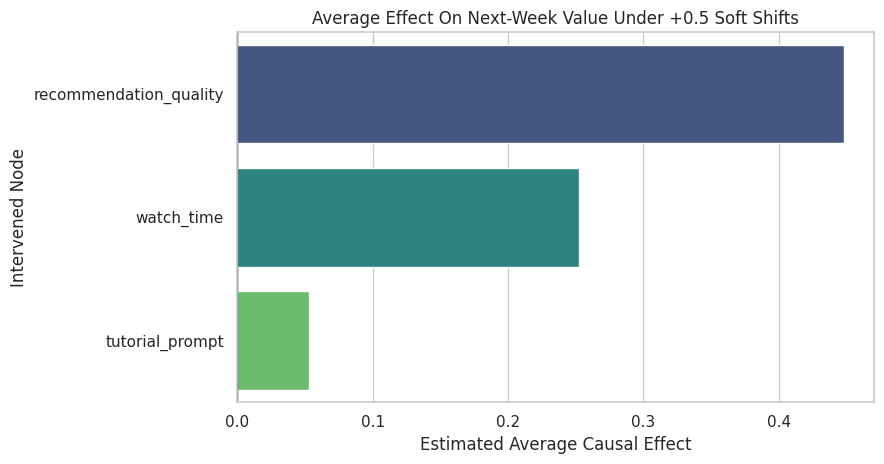

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=ace_table,
    x="estimated_ace",
    y="intervened_node",
    hue="intervened_node",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Average Effect On Next-Week Value Under +0.5 Soft Shifts")
ax.set_xlabel("Estimated Average Causal Effect")
ax.set_ylabel("Intervened Node")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_average_causal_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The ranking of the bars tells a policy story: upstream recommendation quality is the strongest lever among these three changes, while direct watch-time shifts represent a more downstream intervention.


### Estimate a Policy Ladder

One benefit of GCM simulation is that we can compare a ladder of intervention intensities. Here we estimate the effect of several recommendation-quality shifts, from mild to aggressive.


In [16]:
quality_shift_amounts = [-0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00]
policy_rows = []
for amount in quality_shift_amounts:
    effect = gcm.average_causal_effect(
        causal_model,
        target_node="next_week_value",
        interventions_alternative={"recommendation_quality": shift_by(amount)},
        interventions_reference={"recommendation_quality": identity_intervention},
        observed_data=ace_base,
    )
    policy_rows.append(
        {
            "quality_shift": amount,
            "estimated_effect_vs_no_shift": effect,
        }
    )
policy_ladder = pd.DataFrame(policy_rows)
policy_ladder.to_csv(TABLE_DIR / "11_quality_policy_ladder.csv", index=False)
display(policy_ladder)


,quality_shift,estimated_effect_vs_no_shift
0,-0.5000,-0.4269
1,-0.2500,-0.2315
2,0.0000,-0.0251
3,0.2500,0.2018
4,0.5000,0.3995
5,0.7500,0.6717
6,1.0000,0.9125


The effect increases as the quality shift becomes more positive. Because the fitted mechanisms are nonlinear, the relationship does not have to be perfectly linear across the whole ladder.


#### Plot the Policy Ladder

The line plot gives a quick view of marginal returns. A straight line would suggest a near-constant effect per unit of quality; visible curvature would suggest effect sizes change as the intervention becomes larger.


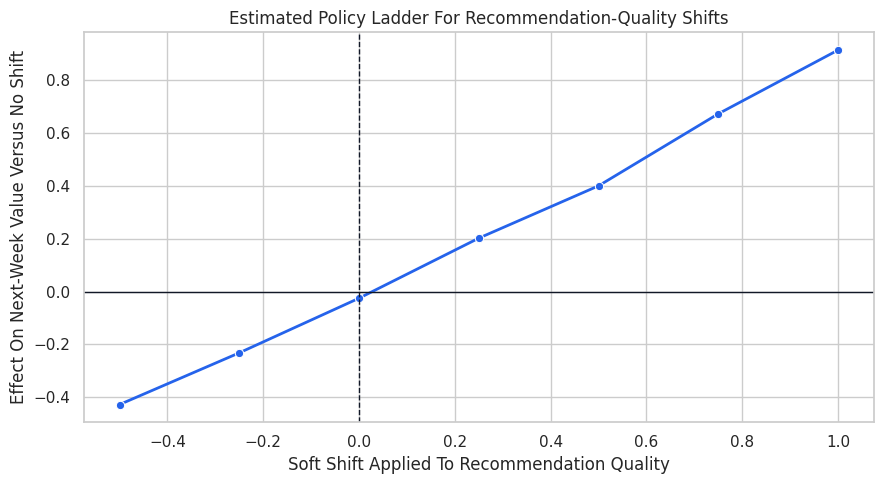

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=policy_ladder,
    x="quality_shift",
    y="estimated_effect_vs_no_shift",
    marker="o",
    linewidth=2,
    color="#2563eb",
    ax=ax,
)
ax.axhline(0, color="#111827", linewidth=1)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("Estimated Policy Ladder For Recommendation-Quality Shifts")
ax.set_xlabel("Soft Shift Applied To Recommendation Quality")
ax.set_ylabel("Effect On Next-Week Value Versus No Shift")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_quality_policy_ladder.png", dpi=160, bbox_inches="tight")
plt.show()


The ladder is smooth and monotonic in this teaching setup. In a real project, this plot is a useful place to look for saturation, harm at high intensity, or implausible extrapolation.




### Compare Hard and Soft Interventions

Soft interventions preserve unit-to-unit differences. Hard interventions overwrite the intervened node with the same value for everyone. Both are useful, but they answer different operational questions.


In [18]:
quality_reference_value = float(gcm_df["recommendation_quality"].median())
quality_high_value = float(gcm_df["recommendation_quality"].quantile(0.75))
hard_soft_rows = []
for label, intervention in [
    ("soft shift: quality +0.5", {"recommendation_quality": shift_by(0.5)}),
    ("hard set: quality at median", {"recommendation_quality": set_to(quality_reference_value)}),
    ("hard set: quality at 75th percentile", {"recommendation_quality": set_to(quality_high_value)}),
]:
    samples = gcm.interventional_samples(
        causal_model,
        interventions=intervention,
        num_samples_to_draw=4_000,
    )
    hard_soft_rows.append(
        {
            "intervention": label,
            "mean_recommendation_quality": samples["recommendation_quality"].mean(),
            "mean_watch_time": samples["watch_time"].mean(),
            "mean_next_week_value": samples["next_week_value"].mean(),
            "std_next_week_value": samples["next_week_value"].std(),
        }
    )
hard_soft_comparison = pd.DataFrame(hard_soft_rows)
hard_soft_comparison.to_csv(TABLE_DIR / "11_hard_vs_soft_interventions.csv", index=False)
display(hard_soft_comparison)


,intervention,mean_recommendation_quality,mean_watch_time,mean_next_week_value,std_next_week_value
0,soft shift: quality +0.5,0.5063,1.6084,1.2381,1.2764
1,hard set: quality at median,-0.0727,1.0128,0.6173,0.6787
2,hard set: quality at 75th percentile,0.4947,1.5775,1.2111,0.7147


The hard interventions compress variation in recommendation quality because everyone receives the same value. The soft shift preserves heterogeneity, which is often closer to how a product-quality improvement would behave.




#### Counterfactuals for Specific Observed Rows

Counterfactuals are different from population interventions. We start from actual observed rows, infer their background noise under the fitted model, change recommendation quality, and recompute downstream consequences for the same rows.


In [19]:
case_study_rows = (
    gcm_df.sample(10, random_state=11)
    .sort_values("next_week_value")
    .reset_index(drop=True)
)
counterfactual_quality_plus = gcm.counterfactual_samples(
    causal_model,
    interventions={"recommendation_quality": shift_by(0.5)},
    observed_data=case_study_rows,
)
counterfactual_table = pd.DataFrame(
    {
        "row_id": np.arange(len(case_study_rows)),
        "observed_quality": case_study_rows["recommendation_quality"],
        "counterfactual_quality": counterfactual_quality_plus["recommendation_quality"],
        "observed_watch_time": case_study_rows["watch_time"],
        "counterfactual_watch_time": counterfactual_quality_plus["watch_time"],
        "observed_next_week_value": case_study_rows["next_week_value"],
        "counterfactual_next_week_value": counterfactual_quality_plus["next_week_value"],
    }
)
counterfactual_table["delta_watch_time"] = (
    counterfactual_table["counterfactual_watch_time"] - counterfactual_table["observed_watch_time"]
)
counterfactual_table["delta_next_week_value"] = (
    counterfactual_table["counterfactual_next_week_value"] - counterfactual_table["observed_next_week_value"]
)
counterfactual_table.to_csv(TABLE_DIR / "11_specific_row_counterfactuals.csv", index=False)
display(counterfactual_table)


,row_id,observed_quality,counterfactual_quality,observed_watch_time,counterfactual_watch_time,observed_next_week_value,counterfactual_next_week_value,delta_watch_time,delta_next_week_value
0,0,0.1099,0.6099,0.6789,0.9125,-0.2042,0.2482,0.2336,0.4524
1,1,-0.6808,-0.1808,-0.0378,0.5160,-0.1452,0.5658,0.5538,0.7110
2,2,-0.6846,-0.1846,0.1653,0.4831,-0.0637,0.3411,0.3178,0.4048
3,3,-0.3895,0.1105,1.2965,1.8350,0.8229,1.1593,0.5386,0.3364
4,4,-0.2899,0.2101,1.8210,2.1828,1.3321,1.7742,0.3618,0.4421
5,5,0.9005,1.4005,1.7793,2.3077,1.3396,1.7937,0.5284,0.4540
6,6,0.8759,1.3759,1.8713,2.3242,1.6030,2.0669,0.4529,0.4639
7,7,-0.2381,0.2619,2.0054,2.3727,1.6096,1.9314,0.3673,0.3219
8,8,0.6977,1.1977,2.4794,3.0505,2.2540,2.9398,0.5711,0.6858
9,9,0.8861,1.3861,1.9746,2.3609,2.3331,2.7622,0.3863,0.4291


Each row keeps its own inferred background factors. The recommendation-quality change is the same `+0.5` shift, but downstream deltas vary because the fitted structural functions are nonlinear and depend on each row's context.


#### Visualize Individual Counterfactual Movement

The next plot connects each observed row to its counterfactual outcome. This is a compact way to see which specific rows would have moved the most under the same quality improvement.


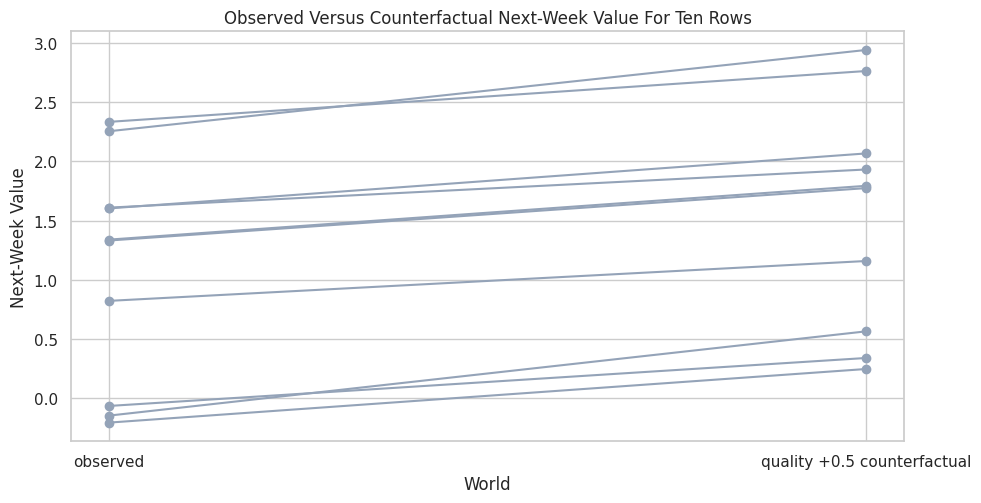

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.2))
for _, row in counterfactual_table.iterrows():
    ax.plot(
        ["observed", "quality +0.5 counterfactual"],
        [row["observed_next_week_value"], row["counterfactual_next_week_value"]],
        color="#94a3b8",
        linewidth=1.5,
        marker="o",
    )
ax.set_title("Observed Versus Counterfactual Next-Week Value For Ten Rows")
ax.set_xlabel("World")
ax.set_ylabel("Next-Week Value")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_specific_row_counterfactual_movements.png", dpi=160, bbox_inches="tight")
plt.show()


Most rows move upward, but the amount of movement differs. This is the row-level perspective that an average causal effect compresses into one number.


#### Counterfactual Deltas Across a Larger Sample

A ten-row table is good for learning mechanics. A larger sample shows the distribution of individual-level counterfactual effects under the same quality shift.


In [21]:
cf_base = gcm_df.sample(800, random_state=22).reset_index(drop=True)
cf_quality_plus = gcm.counterfactual_samples(
    causal_model,
    interventions={"recommendation_quality": shift_by(0.5)},
    observed_data=cf_base,
)
counterfactual_deltas = cf_base[["user_intent", "catalog_match", "tutorial_prompt", "recommendation_quality", "watch_time", "next_week_value"]].copy()
counterfactual_deltas["cf_recommendation_quality"] = cf_quality_plus["recommendation_quality"]
counterfactual_deltas["cf_watch_time"] = cf_quality_plus["watch_time"]
counterfactual_deltas["cf_next_week_value"] = cf_quality_plus["next_week_value"]
counterfactual_deltas["delta_watch_time"] = counterfactual_deltas["cf_watch_time"] - counterfactual_deltas["watch_time"]
counterfactual_deltas["delta_next_week_value"] = counterfactual_deltas["cf_next_week_value"] - counterfactual_deltas["next_week_value"]
cf_delta_summary = counterfactual_deltas[["delta_watch_time", "delta_next_week_value"]].describe().T.reset_index(names="delta")
cf_delta_summary.to_csv(TABLE_DIR / "11_counterfactual_delta_summary.csv", index=False)
display(cf_delta_summary)


,delta,count,mean,std,min,25%,50%,75%,max
0,delta_watch_time,800.0000,0.4051,0.1569,0.0000,0.3115,0.3996,0.4802,1.2532
1,delta_next_week_value,800.0000,0.4321,0.1916,0.0000,0.3166,0.4019,0.5175,1.5994


The mean counterfactual gain is close to the average causal effect, but the spread is the new information. Some rows gain much more than others from the same recommendation-quality shift.




#### Plot the Counterfactual Effect Distribution

This distribution shows heterogeneity in row-level counterfactual outcomes. It is not a treatment-effect estimator by itself; it is the fitted GCM's answer to a specific what-if question for observed rows.


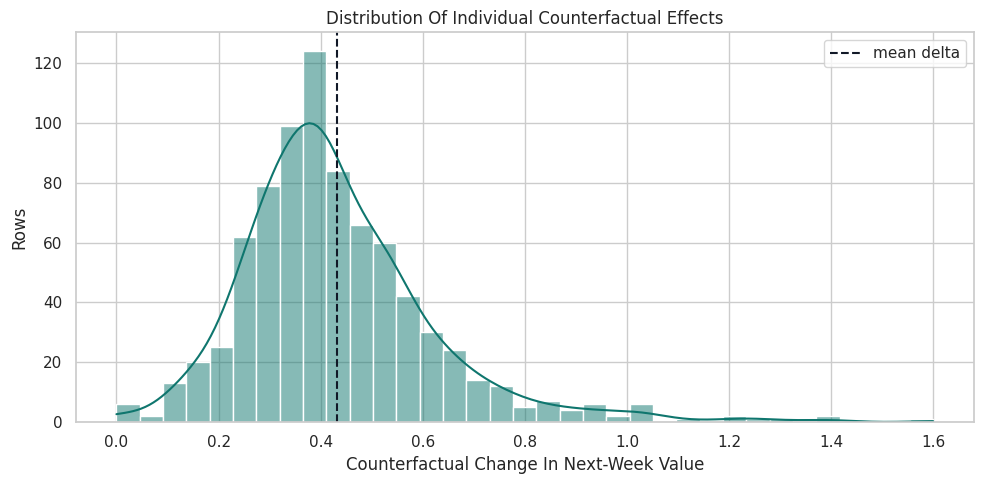

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=counterfactual_deltas,
    x="delta_next_week_value",
    bins=35,
    kde=True,
    color="#0f766e",
    ax=ax,
)
ax.axvline(counterfactual_deltas["delta_next_week_value"].mean(), color="#111827", linestyle="--", linewidth=1.5, label="mean delta")
ax.set_title("Distribution Of Individual Counterfactual Effects")
ax.set_xlabel("Counterfactual Change In Next-Week Value")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_counterfactual_effect_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The histogram makes the individual-level story concrete. A single average effect hides the left tail, the right tail, and the practical question of who is most responsive.




#### Explore Which Rows Benefit More

Because counterfactual deltas are row-level quantities, we can relate them back to observed context. The code below checks whether baseline user intent and current recommendation quality are associated with larger counterfactual gains.


In [23]:
counterfactual_deltas["intent_bucket"] = pd.qcut(
    counterfactual_deltas["user_intent"],
    q=4,
    labels=["lowest intent", "low-mid intent", "high-mid intent", "highest intent"],
)
counterfactual_deltas["quality_bucket"] = pd.qcut(
    counterfactual_deltas["recommendation_quality"],
    q=4,
    labels=["lowest quality", "low-mid quality", "high-mid quality", "highest quality"],
)
responsiveness_by_bucket = (
    counterfactual_deltas.groupby(["intent_bucket", "quality_bucket"], observed=True)
    .agg(
        rows=("delta_next_week_value", "size"),
        mean_delta=("delta_next_week_value", "mean"),
        median_delta=("delta_next_week_value", "median"),
    )
    .reset_index()
)
responsiveness_by_bucket.to_csv(TABLE_DIR / "11_counterfactual_responsiveness_by_bucket.csv", index=False)
display(responsiveness_by_bucket.head(12))


,intent_bucket,quality_bucket,rows,mean_delta,median_delta
0,lowest intent,lowest quality,130,0.3196,0.3159
1,lowest intent,low-mid quality,55,0.3929,0.3755
2,lowest intent,high-mid quality,15,0.5450,0.5513
3,low-mid intent,lowest quality,47,0.3307,0.3346
4,low-mid intent,low-mid quality,80,0.3599,0.3686
5,low-mid intent,high-mid quality,63,0.4892,0.4909
6,low-mid intent,highest quality,10,0.4822,0.4822
7,high-mid intent,lowest quality,17,0.4461,0.4329
8,high-mid intent,low-mid quality,48,0.3664,0.3610
9,high-mid intent,high-mid quality,68,0.4600,0.4570


The grouped table starts to tell a targeting story: the same upstream quality improvement can matter differently depending on baseline intent and current quality. In real work, this would be followed by careful validation rather than immediate personalization.


#### Heatmap of Counterfactual Responsiveness

The table is useful but dense. A heatmap makes the interaction between baseline intent and current quality easier to scan.


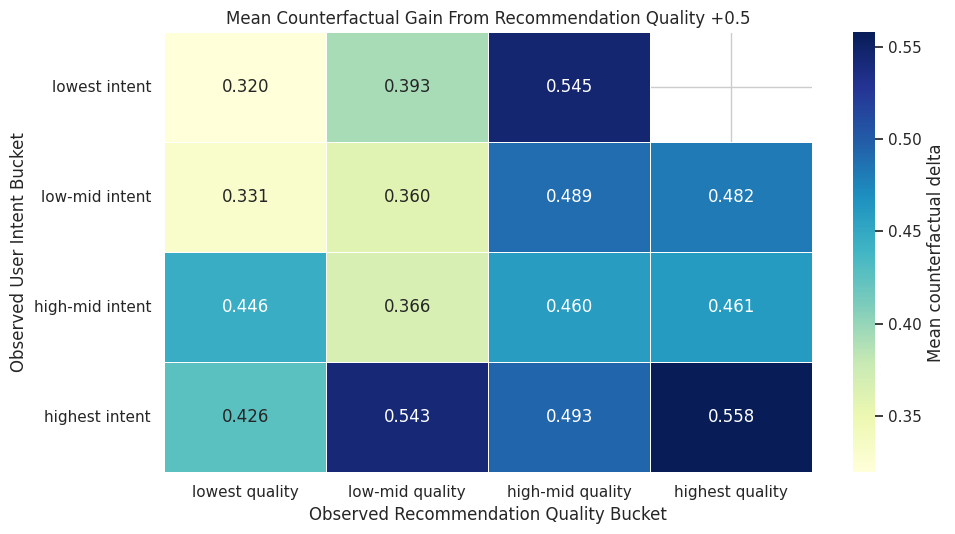

In [24]:
heatmap_df = responsiveness_by_bucket.pivot(
    index="intent_bucket",
    columns="quality_bucket",
    values="mean_delta",
)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Mean counterfactual delta"},
    ax=ax,
)
ax.set_title("Mean Counterfactual Gain From Recommendation Quality +0.5")
ax.set_xlabel("Observed Recommendation Quality Bucket")
ax.set_ylabel("Observed User Intent Bucket")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_counterfactual_responsiveness_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap shows how counterfactual analysis can support exploratory segmentation. The numbers are model-based what-if outputs, so they are best used to generate hypotheses and decision rules that can later be tested.




#### Compare GCM Estimates with the Known Simulator

Because this is synthetic example data, we can compute an oracle counterfactual using the true structural equations and the true hidden noise. Real datasets do not give us this luxury. The comparison is valuable for learning what the GCM is trying to approximate.


In [25]:
# Define reusable helpers for the Compare GCM Estimates With The Known Simulator section.
def structural_forward(user_intent, catalog_match, tutorial_prompt, eps_quality, eps_watch, eps_value, quality_shift=0.0):
    """
    Run the known teaching simulator under an optional recommendation-quality shift.
    
    Parameters
    ----------
    user_intent : object
        User-intent variable used in the structural forward simulation.
    catalog_match : object
        Catalog-match variable used in the structural forward simulation.
    tutorial_prompt : object
        Prompt text shown or passed through the tutorial intervention helper.
    eps_quality : object
        Random shock for recommendation quality in the structural simulation.
    eps_watch : object
        Random shock for watch time in the structural simulation.
    eps_value : float
        Numeric value for `eps`.
    quality_shift : object
        Intervention shift applied to recommendation quality.
    
    Returns
    -------
    pd.DataFrame
        Forward-simulated structural outcomes for recommendation quality, watch time, and next-week value.
    """
    recommendation_quality = (
        0.55 * user_intent
        + 0.35 * catalog_match
        + 0.18 * user_intent * catalog_match
        + eps_quality
        + quality_shift
    )
    watch_time = (
        1.10
        + 0.75 * recommendation_quality
        + 0.25 * tutorial_prompt
        + 0.35 * user_intent
        + 0.18 * recommendation_quality * user_intent
        + eps_watch
    )
    next_week_value = (
        0.35 * recommendation_quality
        + 0.60 * watch_time
        + 0.20 * user_intent
        - 0.10 * tutorial_prompt
        + 0.08 * watch_time * user_intent
        + eps_value
    )
    return pd.DataFrame(
        {
            "recommendation_quality": recommendation_quality,
            "watch_time": watch_time,
            "next_week_value": next_week_value,
        }
    )
oracle_baseline = structural_forward(
    user_intent=user_intent,
    catalog_match=catalog_match,
    tutorial_prompt=tutorial_prompt,
    eps_quality=eps_quality,
    eps_watch=eps_watch,
    eps_value=eps_value,
    quality_shift=0.0,
)
oracle_quality_plus = structural_forward(
    user_intent=user_intent,
    catalog_match=catalog_match,
    tutorial_prompt=tutorial_prompt,
    eps_quality=eps_quality,
    eps_watch=eps_watch,
    eps_value=eps_value,
    quality_shift=0.5,
)
oracle_effect = float((oracle_quality_plus["next_week_value"] - oracle_baseline["next_week_value"]).mean())
fitted_effect = float(counterfactual_deltas["delta_next_week_value"].mean())
oracle_comparison = pd.DataFrame(
    [
        {
            "quantity": "mean individual counterfactual effect of quality +0.5",
            "oracle_from_known_simulator": oracle_effect,
            "gcm_counterfactual_estimate": fitted_effect,
            "absolute_difference": abs(oracle_effect - fitted_effect),
        }
    ]
)
oracle_comparison.to_csv(TABLE_DIR / "11_oracle_vs_gcm_counterfactual.csv", index=False)
display(oracle_comparison)


,quantity,oracle_from_known_simulator,gcm_counterfactual_estimate,absolute_difference
0,mean individual counterfactual effect of quality +0.5,0.4060,0.4321,0.0261


The fitted GCM estimate is close to the known simulator in this controlled setup. That does not happen automatically; it depends on the graph being correct, the mechanisms being flexible enough, and the intervention staying within a reasonable data range.


#### Compare Population Interventions and Row-Level Counterfactuals

The two workflows can produce similar averages, but they are conceptually different. The code below puts their summary values side by side so the distinction is easy to remember.


In [26]:
population_intervention_effect = float(
    quality_shift_samples["next_week_value"].mean() - model_samples["next_week_value"].mean()
)
row_counterfactual_effect = float(counterfactual_deltas["delta_next_week_value"].mean())
ace_effect = float(quality_ace)
sampling_mode_comparison = pd.DataFrame(
    [
        {
            "mode": "interventional samples",
            "estimate": population_intervention_effect,
            "plain meaning": "Difference in generated population means between shifted and natural worlds.",
        },
        {
            "mode": "average_causal_effect",
            "estimate": ace_effect,
            "plain meaning": "Direct GCM comparison of two intervention worlds on a fixed base sample.",
        },
        {
            "mode": "counterfactual samples",
            "estimate": row_counterfactual_effect,
            "plain meaning": "Mean row-level what-if delta for observed rows after preserving inferred noise.",
        },
    ]
)
sampling_mode_comparison.to_csv(TABLE_DIR / "11_sampling_mode_comparison.csv", index=False)
display(sampling_mode_comparison)


,mode,estimate,plain meaning
0,interventional samples,0.4314,Difference in generated population means between shifted and natural worlds.
1,average_causal_effect,0.4479,Direct GCM comparison of two intervention worlds on a fixed base sample.
2,counterfactual samples,0.4321,Mean row-level what-if delta for observed rows after preserving inferred noise.


The values are in the same neighborhood, which is reassuring, but each row in the table answers a different question. This is why reports should name the estimand and sampling mode explicitly.




#### Multi-Node Interventions

GCM interventions can change multiple nodes at once. Here we test a combined policy: improve recommendation quality while slightly reducing tutorial prompt intensity. This resembles asking whether we can improve the core experience and reduce friction at the same time.


In [27]:
combined_policy_samples = gcm.interventional_samples(
    causal_model,
    interventions={
        "recommendation_quality": shift_by(0.5),
        "tutorial_prompt": shift_by(-0.25),
    },
    num_samples_to_draw=4_000,
)
combined_policy_summary = pd.DataFrame(
    [
        {
            "world": "observed system",
            "mean_quality": gcm_df["recommendation_quality"].mean(),
            "mean_prompt": gcm_df["tutorial_prompt"].mean(),
            "mean_watch_time": gcm_df["watch_time"].mean(),
            "mean_next_week_value": gcm_df["next_week_value"].mean(),
        },
        {
            "world": "quality +0.5 only",
            "mean_quality": quality_shift_samples["recommendation_quality"].mean(),
            "mean_prompt": quality_shift_samples["tutorial_prompt"].mean(),
            "mean_watch_time": quality_shift_samples["watch_time"].mean(),
            "mean_next_week_value": quality_shift_samples["next_week_value"].mean(),
        },
        {
            "world": "quality +0.5 and prompt -0.25",
            "mean_quality": combined_policy_samples["recommendation_quality"].mean(),
            "mean_prompt": combined_policy_samples["tutorial_prompt"].mean(),
            "mean_watch_time": combined_policy_samples["watch_time"].mean(),
            "mean_next_week_value": combined_policy_samples["next_week_value"].mean(),
        },
    ]
)
combined_policy_summary.to_csv(TABLE_DIR / "11_combined_policy_summary.csv", index=False)
display(combined_policy_summary)


,world,mean_quality,mean_prompt,mean_watch_time,mean_next_week_value
0,observed system,-0.0063,-0.0064,1.2006,0.7805
1,quality +0.5 only,0.4841,-0.0199,1.5981,1.2267
2,quality +0.5 and prompt -0.25,0.5011,-0.2726,1.5588,1.2279


The combined intervention changes two parts of the system at once. In this example data, reducing prompt intensity can remove some direct friction, but it can also reduce the prompt's positive path through watch time, so the net comparison needs to be read carefully.


#### Visualize Policy Worlds Together

The final policy plot compares the natural world, the quality-only intervention, and the combined policy on the same outcome distribution.


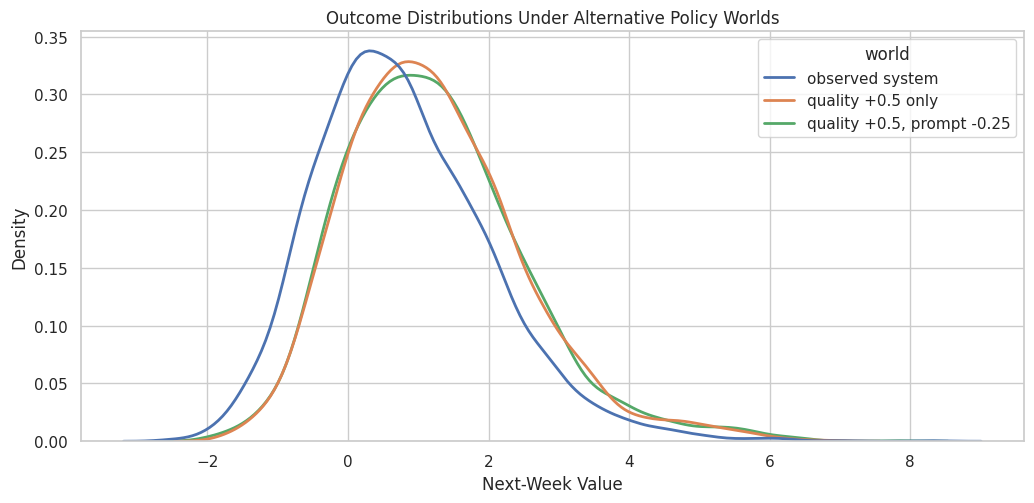

In [28]:
policy_world_plot_df = pd.concat(
    [
        gcm_df[["next_week_value"]].assign(world="observed system"),
        quality_shift_samples[["next_week_value"]].assign(world="quality +0.5 only"),
        combined_policy_samples[["next_week_value"]].assign(world="quality +0.5, prompt -0.25"),
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.kdeplot(
    data=policy_world_plot_df,
    x="next_week_value",
    hue="world",
    common_norm=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Outcome Distributions Under Alternative Policy Worlds")
ax.set_xlabel("Next-Week Value")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_policy_world_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


Plotting the whole distribution helps avoid over-indexing on the mean. In applied work, tails, variance, and subgroup movement may matter as much as the average outcome.





## Reporting and Takeaways

### Practical Checklist

This checklist summarizes the discipline needed when using GCM intervention and counterfactual tools. The code may be short, but the assumptions are doing real work.


| step | question to ask | failure mode |
| --- | --- | --- |
| State the causal graph | Which variables are recomputed after the intervention, and which stay upstream? | A missing or extra edge can change the intervention distribution. |
| Use an invertible model for counterfactuals | Can the model infer row-level noise for observed units? | Counterfactual samples may be unavailable or conceptually invalid. |
| Check generated data quality | Does the fitted GCM reproduce key observed distributions? | Poor mechanism fit can create misleading simulated worlds. |
| Name the estimand | Is this a population intervention, an average effect, or a row-level counterfactual? | Decision-makers may confuse different what-if quantities. |
| Stay near support | Is the intervention value plausible given the observed data? | Large extrapolations can be driven by model outputs. |
| Validate before acting | Can the proposed intervention be tested prospectively? | Simulation can become a substitute for measurement. |


The most important habit is to report what was changed, what was held fixed, and which graph made that propagation possible. Without those details, GCM outputs are too easy to overstate.


## Final Summary

This lesson used DoWhy GCM tools to move beyond a single treatment-effect estimate:

- `gcm.interventional_samples` simulated full population distributions under changed system rules.
- `gcm.average_causal_effect` compared two intervention worlds for the same target node.
- `gcm.counterfactual_samples` reconstructed row-level what-if outcomes after preserving inferred structural noise.
- Hard and soft interventions answered different operational questions.
- The known teaching simulator let us verify that the fitted GCM was approximating the intended counterfactual quantity.

The sequence next returns to the classic DoWhy causal-inference workflow and focuses on mediation, where an effect is decomposed into direct and indirect pathways.
